## 03_bar_charts.ipynb

In [76]:
import pandas as pd
import sqlite3

In [77]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)

## Analyze only the users, not the admins.

In [78]:
query = """
        SELECT
            date(timestamp) AS date,
            CAST(strftime('%H', timestamp) AS INTEGER) AS hour,
            CASE
                WHEN strftime('%w',timestamp) IN ('0','6') THEN 'weekend'
                ELSE 'working_day'
            END AS day_type,
            COUNT (*) AS commits
            FROM checker
            WHERE uid LIKE 'user_%'
            GROUP BY date, hour, day_type
        """

data = pd.read_sql(query, conn)

## For each hour, calculate the average number of commits on working days and weekends. If there were no commits in an hour, do not use it to calculate the average. Use these values for your graph.

In [79]:
avg_df = (
    data.groupby(['hour', 'day_type'])['commits']
    .mean()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
)
avg_df

day_type,weekend,working_day
hour,,
0,2.000000,3.000000
1,6.000000,0.000000
2,0.000000,0.000000
3,1.000000,2.000000
4,0.000000,0.000000
5,2.000000,7.500000
6,0.000000,1.500000
7,4.000000,5.166667
8,7.000000,3.700000


## Create a graph

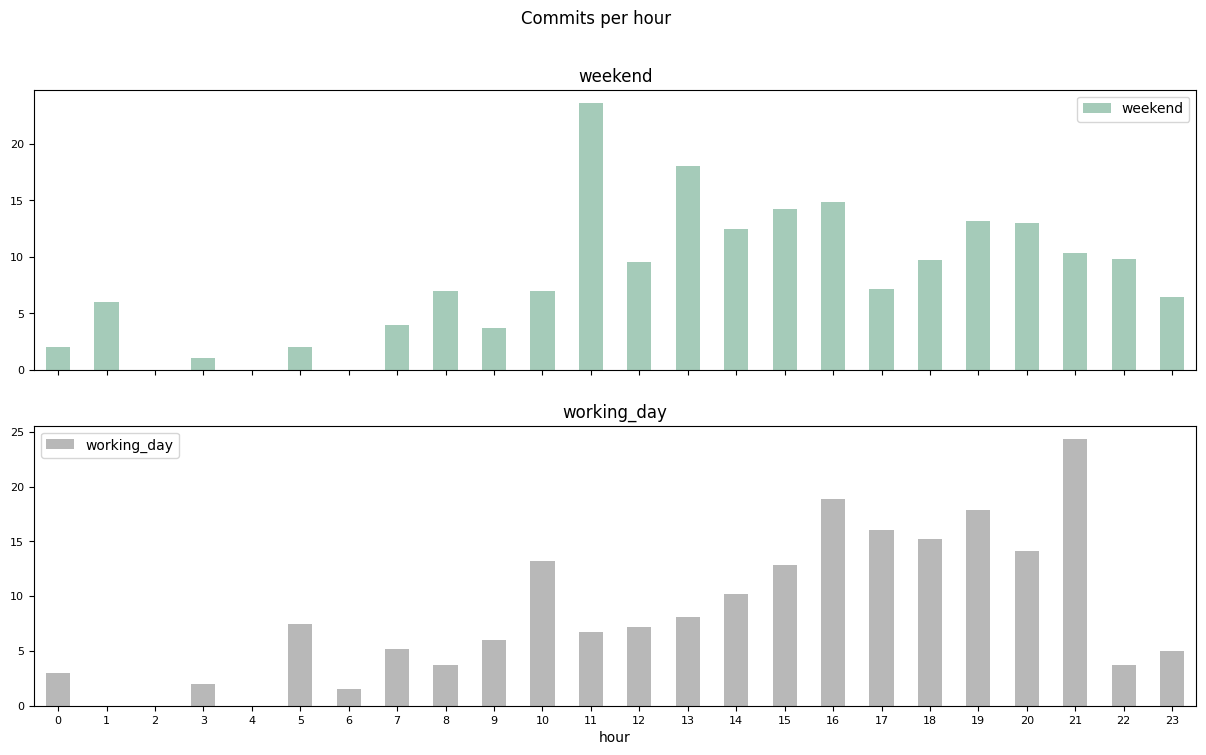

In [80]:
colors = {
    'weekend': '#A5CBB9',
    'working_day': '#B8B8B8',
}

weekend_plot, working_day_plot = avg_df.plot(
    fontsize=8,
    figsize=(15,8),
    title='Commits per hour',
    rot=0,
    kind='bar',
    subplots=True,
    color=colors
)

In [81]:
conn.close()

## "Is the dynamic different on working days and weekends?" For the answer, include the hour when the number of commits is largest during working days and the hour when it is largest during the weekend.

In [82]:
working_day_peak = avg_df['working_day'].idxmax()
weekend_peak = avg_df['weekend'].idxmax()
print(f"{working_day_peak}, {weekend_peak}")

21, 11
